In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import seaborn as sns

df=pd.read_csv('./cardio_train.csv')
#split the data into a half
data=df.sample(frac=0.5,random_state=42)
#changing age from days to years
data['age']=(data['age']/365).astype('int')

Data cleaning process
1) check if data has null values and display correlation
2) remove id
3) standarize the data
4) put together lifestyle columns(alcoho,smoke,active)

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


<Axes: >

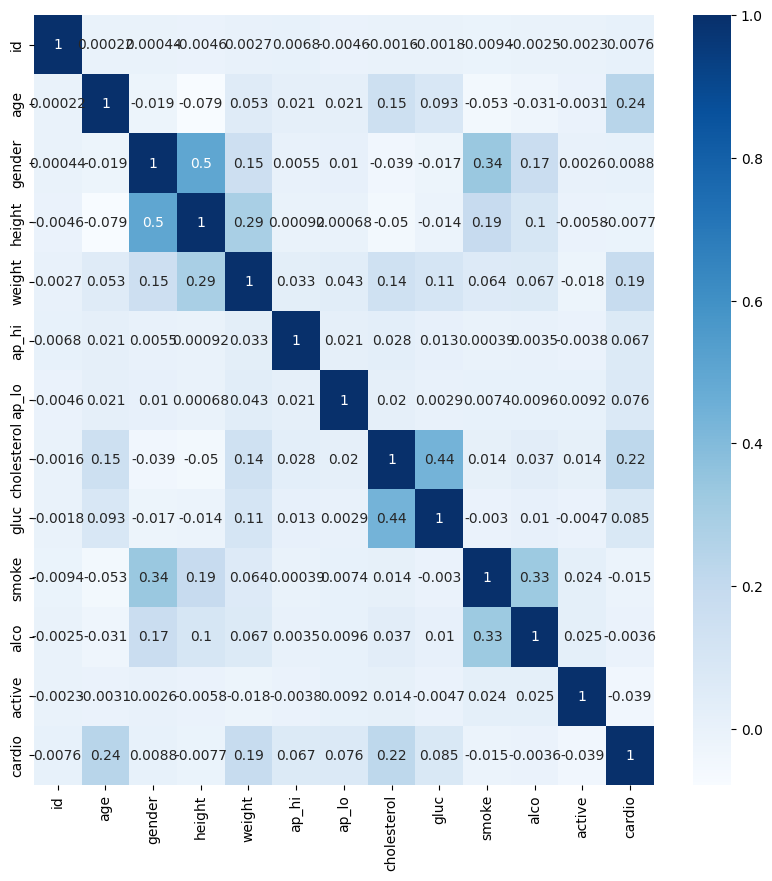

In [19]:
print(data.isnull().sum())
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),cmap="Blues",annot=True)


datas have a poor relationship with cardio the output class

In [23]:
data['lifestyle_score']=data['smoke']+data['alco']+(1-data['active'])
data.drop(['id','smoke','active','alco'],axis=1)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,cardio,lifestyle_score
46730,59,1,156,64.0,140,80,2,1,1,0
48393,59,1,170,85.0,160,90,1,1,1,0
41416,63,1,151,90.0,130,80,1,1,1,0
34506,54,1,159,97.0,120,80,1,1,1,0
43725,50,1,164,68.0,120,80,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
32071,55,1,144,57.0,140,80,1,1,0,0
18435,51,1,160,68.0,160,90,2,1,1,0
22904,55,1,164,69.0,120,80,3,3,1,1
29840,57,1,165,65.0,140,80,1,1,1,0


In [5]:
X=data.drop(['cardio'],axis=1)

y=data['cardio']
X_scaled=StandardScaler().fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.4,random_state=42)
X

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
46730,66728,59,1,156,64.0,140,80,2,1,0,0,1
48393,69098,59,1,170,85.0,160,90,1,1,0,0,1
41416,59185,63,1,151,90.0,130,80,1,1,0,0,1
34506,49288,54,1,159,97.0,120,80,1,1,0,0,1
43725,62481,50,1,164,68.0,120,80,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
32071,45793,55,1,144,57.0,140,80,1,1,0,0,1
18435,26323,51,1,160,68.0,160,90,2,1,0,0,1
22904,32716,55,1,164,69.0,120,80,3,3,0,0,0
29840,42669,57,1,165,65.0,140,80,1,1,0,0,1


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation

model = Sequential([
    Dense(128, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

optimizer = Adam(learning_rate=0.001)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    factor=0.5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history=model.fit(X_train,y_train,epochs=20,batch_size=64,validation_split=0.2,
                  callbacks=[early_stop,lr_scheduler],
                  )
model.summary

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5695 - loss: 0.7209 - val_accuracy: 0.6552 - val_loss: 0.6220 - learning_rate: 0.0010
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6649 - loss: 0.6154 - val_accuracy: 0.6950 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6904 - loss: 0.5936 - val_accuracy: 0.7138 - val_loss: 0.5791 - learning_rate: 0.0010
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7096 - loss: 0.5750 - val_accuracy: 0.7224 - val_loss: 0.5647 - learning_rate: 0.0010
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7175 - loss: 0.5674 - val_accuracy: 0.7236 - val_loss: 0.5632 - learning_rate: 0.0010
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7194 - loss: 0.5659 - val_accuracy: 0.7245 - val_loss: 0.5592 - learning_rate: 0.0010
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7202 - loss: 0.5607 - 

<bound method Model.summary of <Sequential name=sequential_5, built=True>>

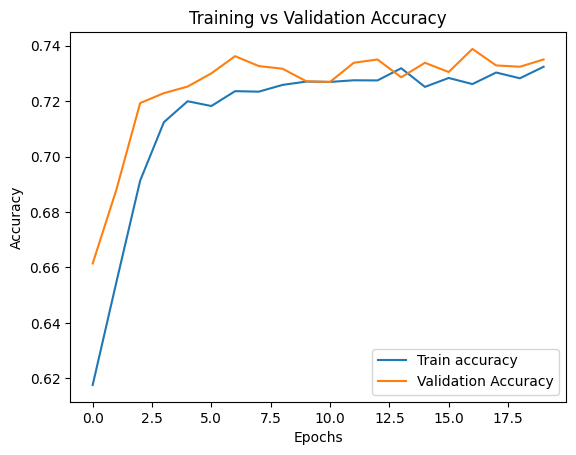

In [41]:
plt.plot(history.history["accuracy"],label='Train accuracy')
plt.plot(history.history["val_accuracy"],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [42]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7334 - loss: 0.5459
Test Accuracy: 0.7306


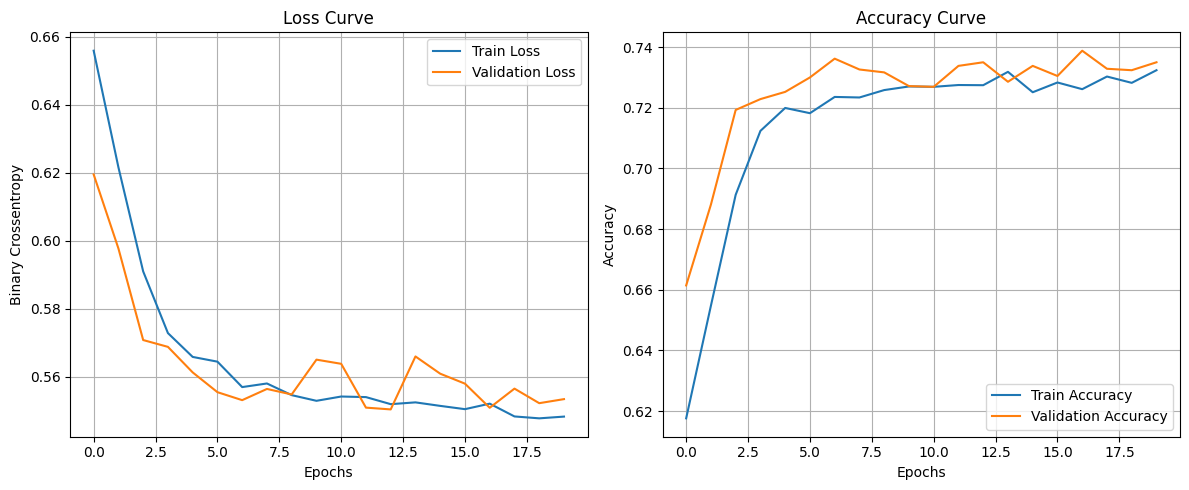

In [ ]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
